# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



# Assignment Answer

# Candidate Test 2022 Analysis Part 2

In this notebook, we analyze Danish political candidate-test answers from DR and TV2.

The answers are on a scale from **-2 to 2**.

Main goals:

1. Find which questions are most important for political placement.
2. Calculate party average positions.
3. Use PCA to create political axes.
4. Use clustering to see if candidates naturally group like parties.
5. Analyze elected candidates.
6. Explain the ML reasoning in a simple way.

# Imports


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"  # Limit to 4 threads

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Datasets


In [2]:

all_data = pd.read_excel("alldata.xlsx")
elected_data = pd.read_excel("electeddata.xlsx")

drq_data = pd.read_excel("drq.xlsx")
tv2q_data = pd.read_excel("tv2q.xlsx")

print("All Candidates:", all_data.shape)
print("Elected Candidates:", elected_data.shape)

display(all_data.head())
display(drq_data.head())
display(tv2q_data.tail(24))


All Candidates: (867, 53)
Elected Candidates: (169, 53)


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


,ID,Title,Question,Info,ArgumentFor,ArgumentAgainst,WordMerger,ID_CandidateQuestionType,Rule,QuestionListData
0,530,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,NaN,Den kollektive trafik bør være billig og tilgæ...,Det er dyrt for statskassen at opretholde drif...,0,1,FT,NaN
1,531,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,NaN,Historisk rammer kriser de fattigste hårdest. ...,Det danske samfund er et af de mest lige samfu...,0,1,FT,NaN
2,533,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...,NaN,Den mest effektive måde at stoppe bandekrimina...,"Det er urimeligt, at den samme forbrydelse ska...",0,1,FT,NaN
3,534,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,NaN,"Så længe Danmark er medlem af EU, kan flertall...",Danmark er bedst tjent med at være en del af E...,0,1,FT,NaN
4,535,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år...",NaN,Ruslands angreb på Ukraine har ændret alting o...,Vi er medlemmer af Nato og har i forvejen et s...,0,1,FT,NaN


,id,type,header,question,depends
50,1a,rate,Miljø og klima,"Oksekød bør pålægges en klimaafgift, således a...",NaN
51,1b,rate,Miljø og klima,"De virksomheder, der udleder mest CO₂, skal be...",NaN
52,2a,rate,Hospitaler og sundhed,Folketinget bør afsætte midler målrettet et lø...,NaN
53,2b,rate,Hospitaler og sundhed,Cigaretter bør pålægges en ekstra afgift på 20...,NaN
54,3a,rate,Udenrigs- og forsvarspolitik,Danmark bør bruge to procent af BNP på forsvar...,NaN
55,3b,rate,Udenrigs- og forsvarspolitik,Ulandsbistanden bør hæves.,NaN
56,4a,rate,Økonomi,Den økonomiske ulighed i det danske samfund bø...,NaN
57,4b,rate,Økonomi,Staten bør i højere grad kompensere danskerne ...,NaN
58,5a,rate,Ældre,Det er nødvendigt at indføre brugerbetaling i ...,NaN
59,5b,rate,Ældre,Der bør tilføres ekstra ressourcer til ældrepl...,NaN


# Define Part Colors

In [3]:

party_colors = {
    "Socialdemokratiet": "#b72722",
    "Radikale Venstre": "#7b3f8c",
    "Det Konservative Folkeparti": "#9ec420",
    "Nye Borgerlige": "#075864",
    "Socialistisk Folkeparti": "#e0007a",
    "Liberal Alliance": "#2ec4c7",
    "Kristendemokraterne": "#bfbfbf",
    "Moderaterne": "#6f35e8",
    "Dansk Folkeparti": "#f4d03f",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#00d66b",
    "Venstre": "#00749e",
    "Danmarksdemokraterne": "#83b9ef",
    "Enhedslisten": "#f58214",
    "Alternativet": "#2d963f",
    "Løsgænger": "#666666",
}

# Data Cleaning


In [4]:
all_clean_data = all_data.copy()
elected_clean_data = elected_data.copy()

all_clean_data["alder"] = all_clean_data["alder"].replace(0, np.nan)
elected_clean_data["alder"] = elected_clean_data["alder"].replace(0, np.nan)

print("Missing values in all candidates:", all_clean_data.isna().sum().sum())
print("Missing values in elected candidates:", elected_clean_data.isna().sum().sum())


Missing values in all candidates: 16
Missing values in elected candidates: 3


# Interpretation
The dataset is already mostly clean. There are no missing response values, no duplicated candidate names, and all response values are within the expected range from -2 to 2.

The only cleaning step is replacing age values equal to 0 with missing values, because age 0 is not meaningful for election candidates.

# Feature Preparation

In [5]:
meta_cols = ["navn", "parti", "storkreds", "alder"]
feature_cols = [col for col in all_clean_data.columns if col not in meta_cols]

dr_cols = [col for col in feature_cols if col.isdigit()]
tv2_cols = [col for col in feature_cols if not col.isdigit()]

X_all = all_clean_data[feature_cols]
X_elected = elected_clean_data[feature_cols]

print("Number of answer columns:", len(feature_cols))
print("DR questions:", len(dr_cols))
print("TV2 questions:", len(tv2_cols))
print("Missing answers in all candidates:", X_all.isna().sum().sum())
print("Missing answers in elected candidates:", X_elected.isna().sum().sum())
print("Answer range:", X_all.min().min(), "to", X_all.max().max())


Number of answer columns: 49
DR questions: 25
TV2 questions: 24
Missing answers in all candidates: 0
Missing answers in elected candidates: 0
Answer range: -2 to 2


### Interpretation
The response columns are separated from metadata columns because later analysis, such as PCA and clustering, should only use political answer variables.

# Question Mapping


In [16]:
dr_questions = drq_data[["ID", "Title", "Question"]].copy()
dr_questions["feature"] = dr_questions["ID"].astype(str)
dr_questions["source"] = "DR"
dr_questions = dr_questions.rename(columns={
    "Title": "topic",
    "Question": "question"
})

tv2_questions = tv2q_data[tv2q_data["id"].isin(tv2_cols)][["id", "header", "question"]].copy()
tv2_questions["feature"] = tv2_questions["id"].astype(str)
tv2_questions["source"] = "TV2"
tv2_questions = tv2_questions.rename(columns={
    "header": "topic"
})

question_map = pd.concat([
    dr_questions[["feature", "source", "topic", "question"]],
    tv2_questions[["feature", "source", "topic", "question"]]
], ignore_index=True)

question_map = question_map.set_index("feature").loc[feature_cols].reset_index()

display(question_map.head())
display(question_map.tail())
print("Mapped questions:", len(question_map))

,feature,source,topic,question
0,530,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
1,531,DR,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...
2,533,DR,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...
3,534,DR,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU
4,535,DR,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år..."


,feature,source,topic,question
44,10b,TV2,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ..."
45,11a,TV2,Mink-sagen,Der har været alt for meget fokus på Mette Fre...
46,11b,TV2,Mink-sagen,"Det bør undersøges, om Mette Frederiksen kan s..."
47,12a,TV2,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ..."
48,12b,TV2,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ..."


Mapped questions: 49


### Interpretation
The response columns use technical question identifiers, so they are mapped back to their original question texts.

This mapping is important because later PCA loadings and party averages will refer to feature IDs. Without this step, it would be difficult to interpret which political issues define the main axes of variation


## PCA Political Landscape

In [17]:
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
pca_points = pca.fit_transform(X_all_scaled)

pca_data = all_clean_data[["navn", "parti", "storkreds", "alder"]].copy()
pca_data["PC1"] = pca_points[:, 0]
pca_data["PC2"] = pca_points[:, 1]

print("Explained variance PC1:", round(pca.explained_variance_ratio_[0], 3))
print("Explained variance PC2:", round(pca.explained_variance_ratio_[1], 3))
print("Total explained variance:", round(pca.explained_variance_ratio_[:2].sum(), 3))

display(pca_data.head())

Explained variance PC1: 0.417
Explained variance PC2: 0.103
Total explained variance: 0.52


,navn,parti,storkreds,alder,PC1,PC2
0,Lars Philipsen Prahm,Moderaterne,Københavns Storkreds,78.0,-3.362185,-1.516930
1,Karsten Hønge,Socialistisk Folkeparti,Fyns Storkreds,64.0,6.091749,1.191952
2,Martin Kelleher-Petersen,Alternativet,Bornholms Storkreds,37.0,4.960182,-1.096007
3,Nicklas Gjedsig Larsen,Alternativet,Nordjyllands Storkreds,28.0,4.037529,0.834949
4,Tom Gillesberg,Løsgænger,Københavns Storkreds,58.0,0.506901,-0.784739


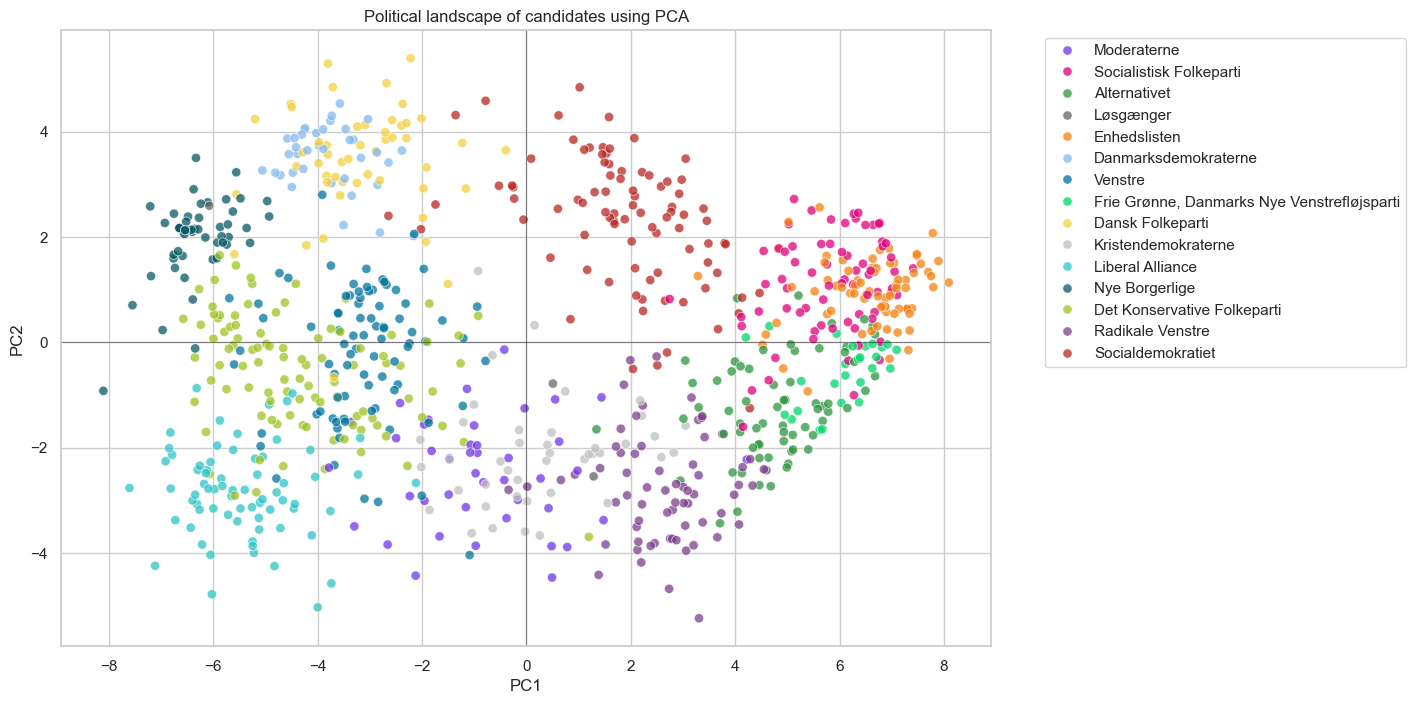

In [18]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="parti",
    palette=party_colors,
    alpha=0.75,
    s=45
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title("Political landscape of candidates using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Interpretation

PCA reduces the 49 political response variables into two main dimensions. Each point represents one candidate, and candidates close to each other gave similar answers.

The plot gives a two-dimensional approximation of the political landscape. The explained variance tells us how much of the total variation in answers is captured by the first two principal components.

## PCA axis interpretation

In [19]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

pca_loadings = pca_loadings.reset_index().rename(columns={"index": "feature"})

loadings_with_questions = pca_loadings.merge(
    question_map,
    on="feature",
    how="left"
)

pc1_important = loadings_with_questions.reindex(
    loadings_with_questions["PC1"].abs().sort_values(ascending=False).index
).head(10)

pc2_important = loadings_with_questions.reindex(
    loadings_with_questions["PC2"].abs().sort_values(ascending=False).index
).head(10)

display(pc1_important[["feature", "source", "topic", "question", "PC1"]])
display(pc2_important[["feature", "source", "topic", "question", "PC2"]])


,feature,source,topic,question,PC1
0,530,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,0.190641
5,537,DR,VELFÆRD,"Det er okay, at den økonomiske ulighed stiger,...",-0.190284
31,4a,TV2,Økonomi,Den økonomiske ulighed i det danske samfund bø...,0.188849
30,3b,TV2,Udenrigs- og forsvarspolitik,Ulandsbistanden bør hæves.,0.188778
15,550,DR,ARBEJDSMARKED OG ØKONOMI,"Der skal indføres kvoter, der sikrer mindst 30...",0.188555
1,531,DR,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,0.187016
9,543,DR,VELFÆRD,"Det er en god idé, at dagpengesatsen for nyudd...",-0.185893
14,548,DR,VELFÆRD,Der skal afsættes penge til at hjælpe kontanth...,0.176281
22,559,DR,KLIMA OG ENERGI,Danmark bør indføre CO2-afgift på flyrejser,0.176279
7,540,DR,VELFÆRD,Det skal være muligt at tjene penge på at driv...,-0.174404


,feature,source,topic,question,PC2
44,10b,TV2,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ...",0.302918
20,556,DR,ARBEJDSMARKED OG ØKONOMI,Den såkaldte Arne-pension skal afskaffes,-0.297979
16,551,DR,EU OG UDENRIGS,Der skal være permanent grænsekontrol mellem D...,0.293836
18,553,DR,UDDANNELSE,Der skal udflyttes flere uddannelsespladser fr...,0.272808
32,4b,TV2,Økonomi,Staten bør i højere grad kompensere danskerne ...,0.258449
33,5a,TV2,Ældre,Det er nødvendigt at indføre brugerbetaling i ...,-0.228295
35,6a,TV2,Flygtninge og indvandrere,Den danske udlændingepolitik er for stram.,-0.208142
36,6b,TV2,Flygtninge og indvandrere,Det vil være en god idé at etablere et dansk a...,0.207708
19,555,DR,EU OG UDENRIGS,Asylansøgere bør sendes til et land uden for E...,0.206750
3,534,DR,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,0.201447


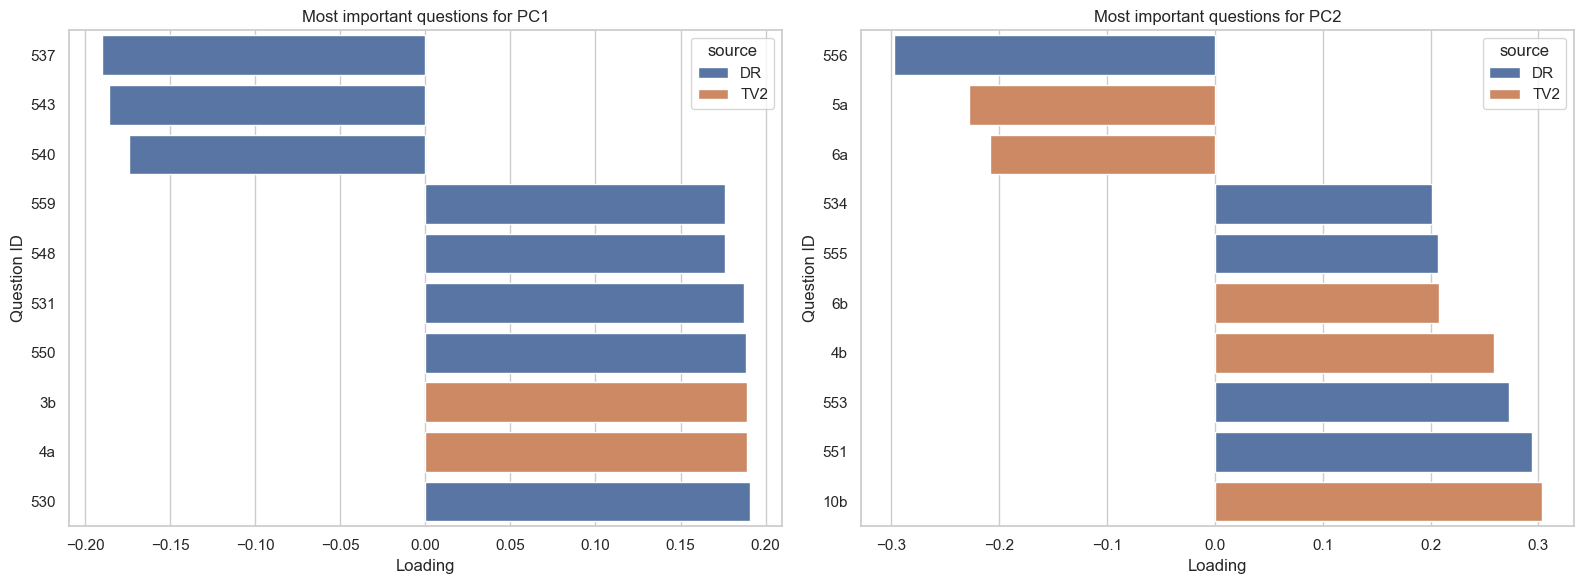

In [20]:
top_pc1 = pc1_important.sort_values("PC1")
top_pc2 = pc2_important.sort_values("PC2")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_pc1,
    x="PC1",
    y="feature",
    hue="source",
    dodge=False,
    ax=axes[0]
)
axes[0].set_title("Most important questions for PC1")
axes[0].set_xlabel("Loading")
axes[0].set_ylabel("Question ID")

sns.barplot(
    data=top_pc2,
    x="PC2",
    y="feature",
    hue="source",
    dodge=False,
    ax=axes[1]
)
axes[1].set_title("Most important questions for PC2")
axes[1].set_xlabel("Loading")
axes[1].set_ylabel("Question ID")

plt.tight_layout()
plt.show()

## Average Party Positions By Question

In [21]:
party_question_avg = all_clean_data.groupby("parti")[feature_cols].mean()

party_question_avg_long = party_question_avg.reset_index().melt(
    id_vars="parti",
    var_name="feature",
    value_name="average_response"
)

party_question_avg_long = party_question_avg_long.merge(
    question_map,
    on="feature",
    how="left"
)

display(party_question_avg_long.head())
print("Rows:", len(party_question_avg_long))


,parti,feature,average_response,source,topic,question
0,Alternativet,530,1.880597,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
1,Danmarksdemokraterne,530,-0.837838,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
2,Dansk Folkeparti,530,-0.571429,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
3,Det Konservative Folkeparti,530,-0.836735,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...
4,Enhedslisten,530,1.959459,DR,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...


Rows: 735


In [22]:
selected_questions = pd.concat([
    pc1_important.head(3),
    pc2_important.head(3)
])["feature"].drop_duplicates().tolist()

selected_questions


['530', '537', '4a', '10b', '556', '551']

Danmark skal bruge flere penge på at styrke tog- og busdrift frem for at bygge nye motorveje


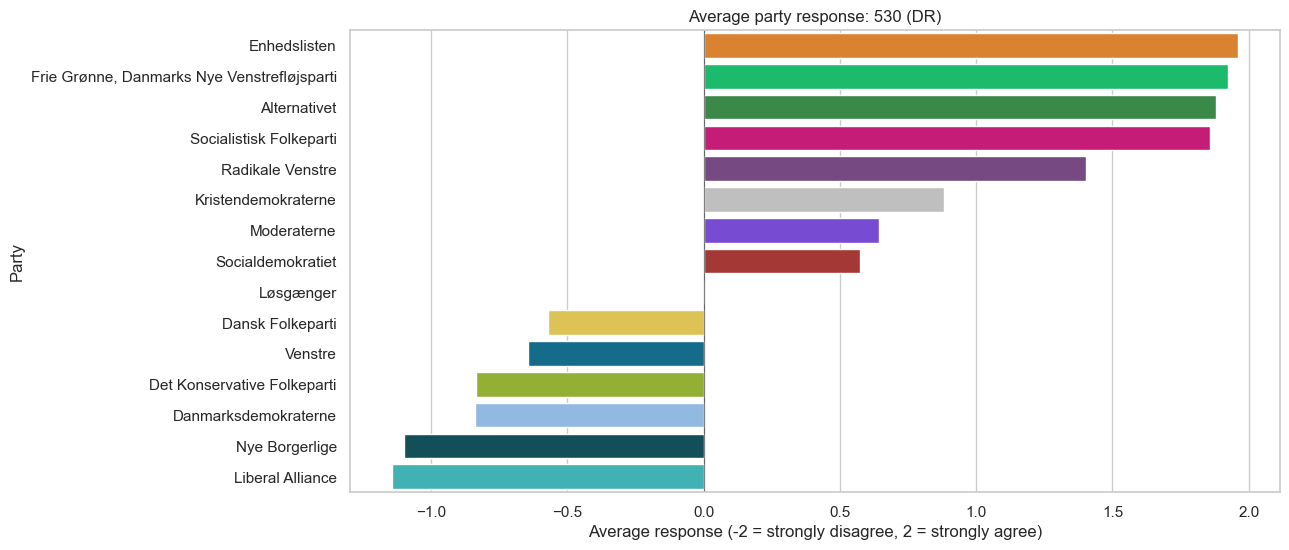


Det er okay, at den økonomiske ulighed stiger, så længe danskerne generelt bliver rigere


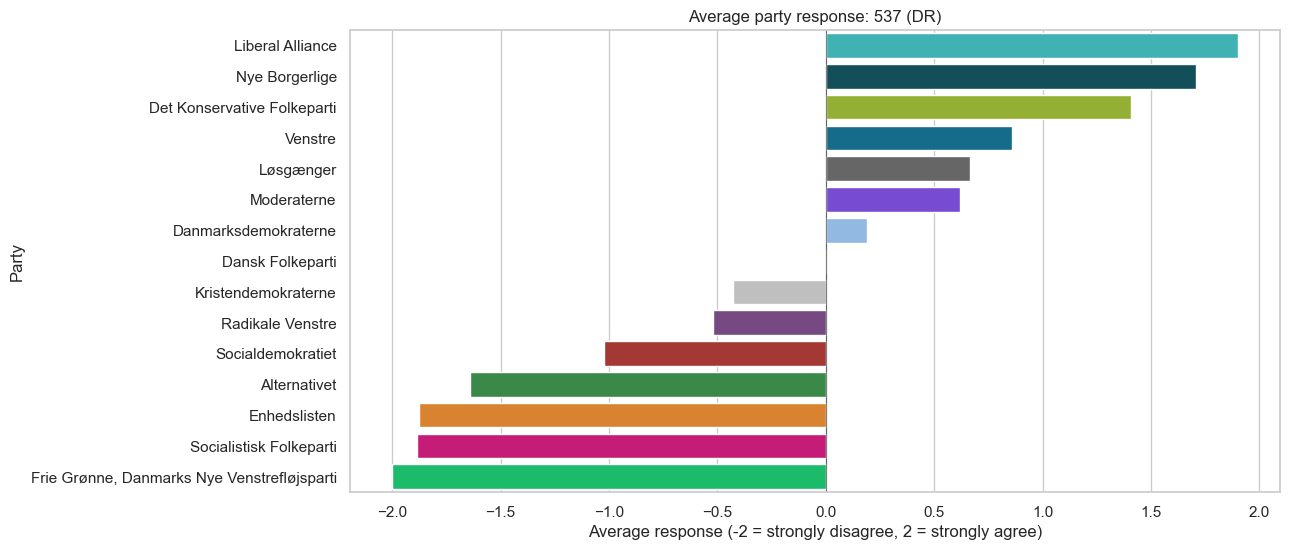


Den økonomiske ulighed i det danske samfund bør mindskes.


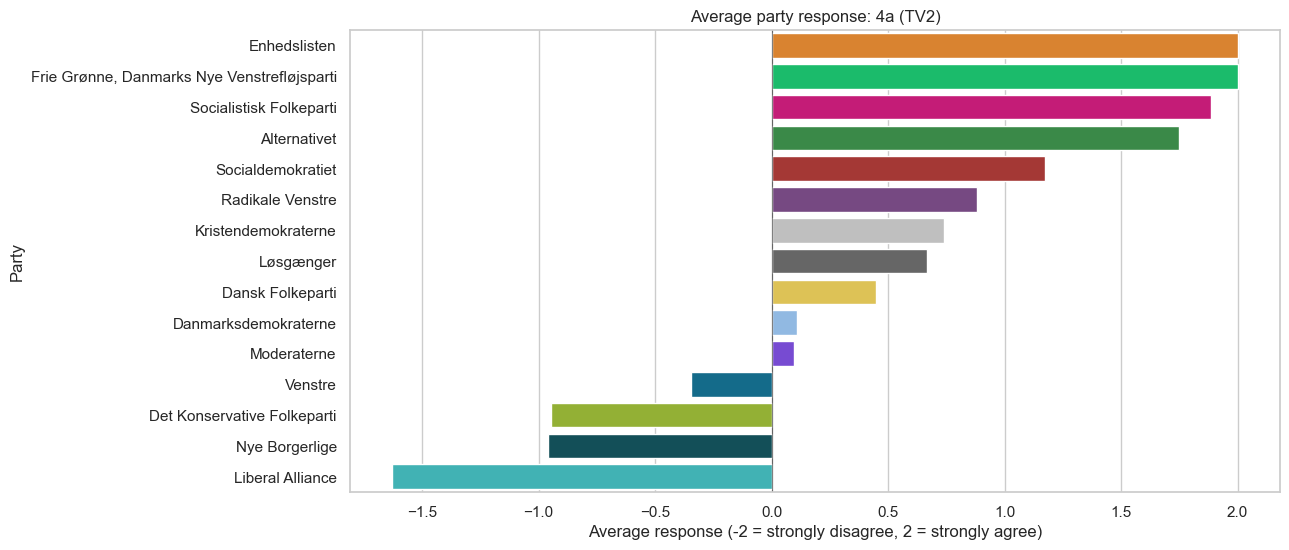


Den såkaldte Arne-pension, der giver mulighed for tidligere pension, skal bibeholdes, selvom der er mangel på arbejdskraft.


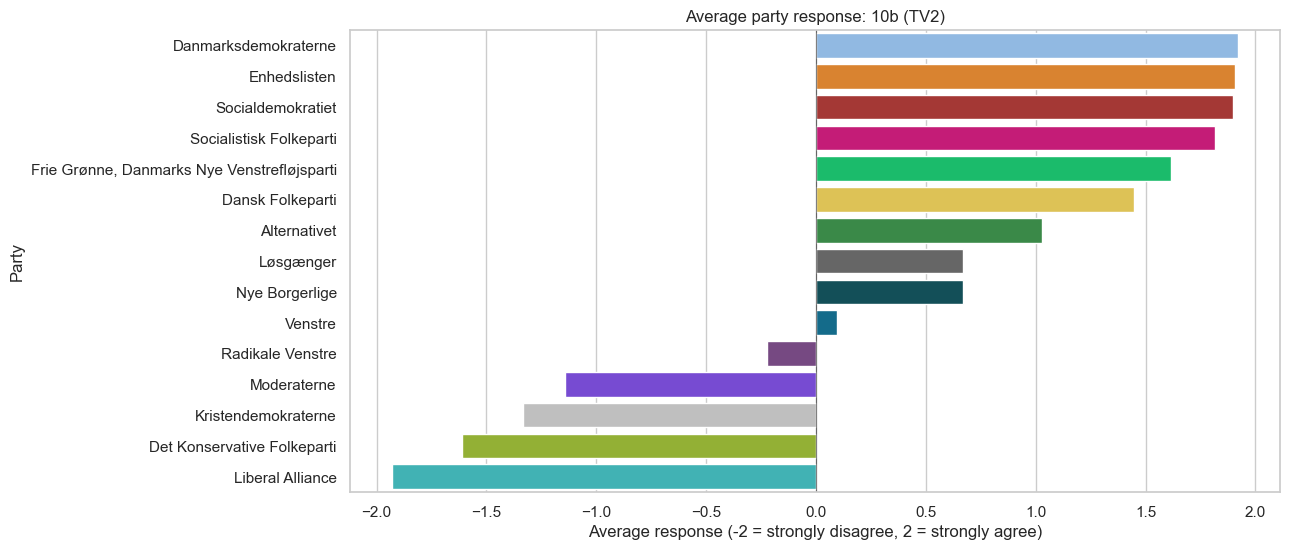


Den såkaldte Arne-pension skal afskaffes


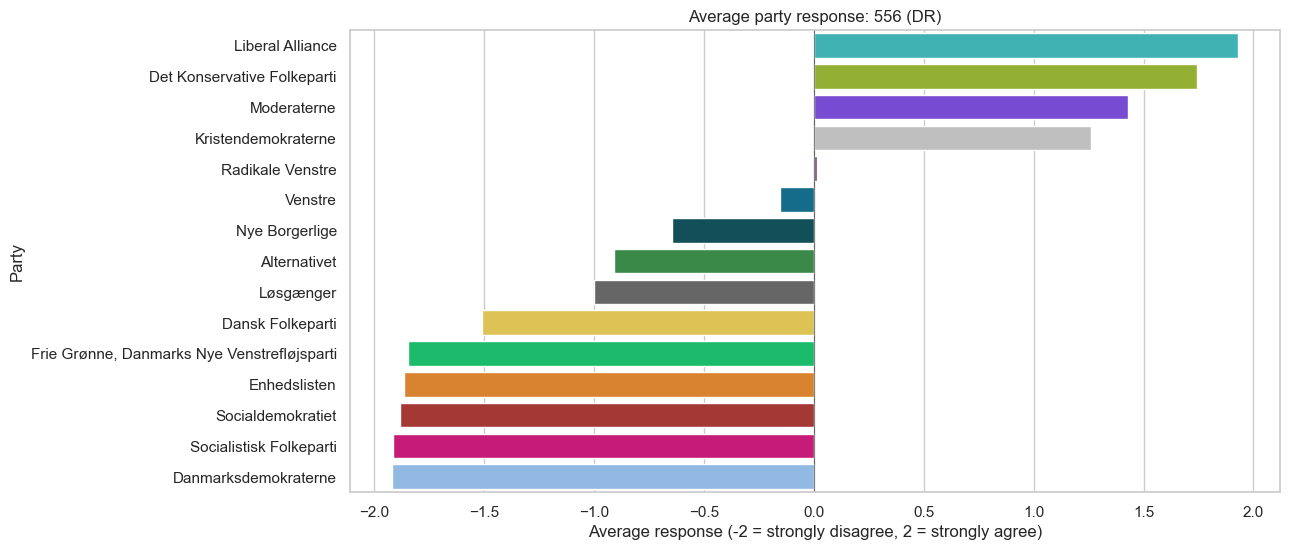


Der skal være permanent grænsekontrol mellem Danmark og Tyskland


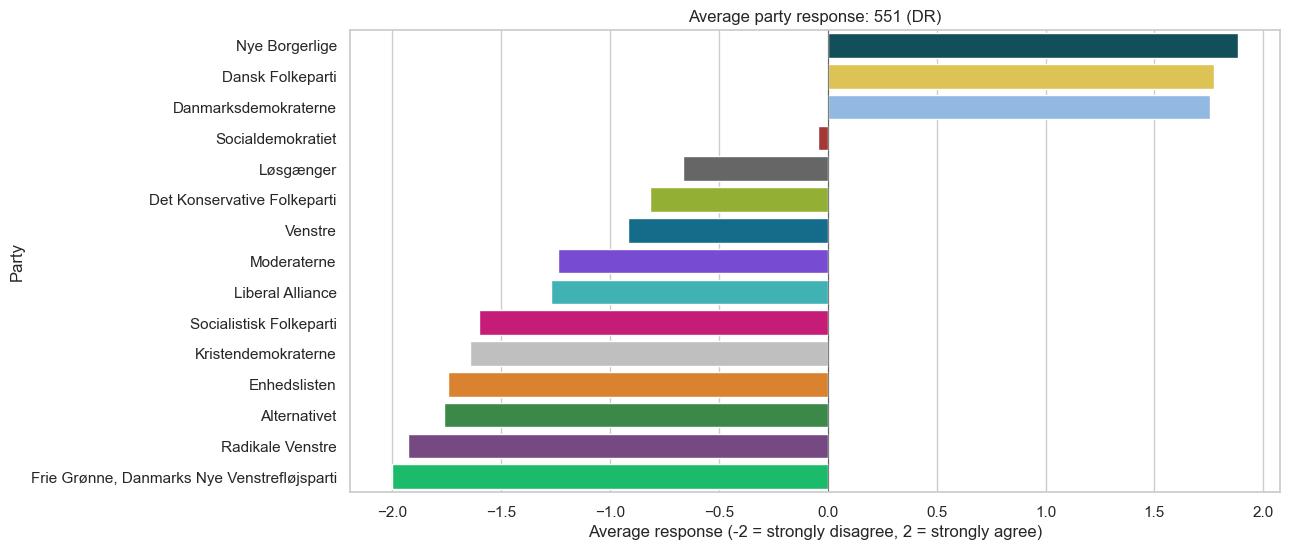

In [23]:
for feature in selected_questions:
    question_info = question_map[question_map["feature"] == feature].iloc[0]
    plot_data = party_question_avg_long[party_question_avg_long["feature"] == feature].sort_values(
        "average_response",
        ascending=False
    )

    print(question_info["question"])
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=plot_data,
        x="average_response",
        y="parti",
        hue="parti",
        palette=party_colors,
        legend=False
    )
    plt.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    plt.title(f"Average party response: {feature} ({question_info['source']})")
    plt.xlabel("Average response (-2 = strongly disagree, 2 = strongly agree)")
    plt.ylabel("Party")
    plt.show()

    print()


### Interpretation

The selected questions show clear party differences and support the PCA interpretation.

PC1 seems mainly related to welfare, inequality, redistribution, and climate policy. Left-wing and green parties are generally more supportive of public spending, reducing inequality, and climate-related policies, while liberal/right-wing parties are more sceptical.

PC2 seems more related to immigration, EU, border control, and welfare reform. Parties such as Nye Borgerlige, Dansk Folkeparti, and Danmarksdemokraterne stand out on border control, while parties such as Radikale Venstre, Frie Gr?nne, Alternativet, and Enhedslisten are strongly opposed.

Overall, the party averages confirm that the PCA axes reflect meaningful political divisions rather than random variation.

## K-Means Clustering

In [25]:
k_values = range(2, 15)
kmeans_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_all_scaled)
    
    score = silhouette_score(X_all_scaled, cluster_labels)
    
    kmeans_results.append({
        "k": k,
        "silhouette_score": score
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

,k,silhouette_score
0,2,0.292870
1,3,0.194576
2,4,0.153307
3,5,0.170655
4,6,0.160133
5,7,0.155038
6,8,0.158373
7,9,0.130454
8,10,0.133523
9,11,0.132223


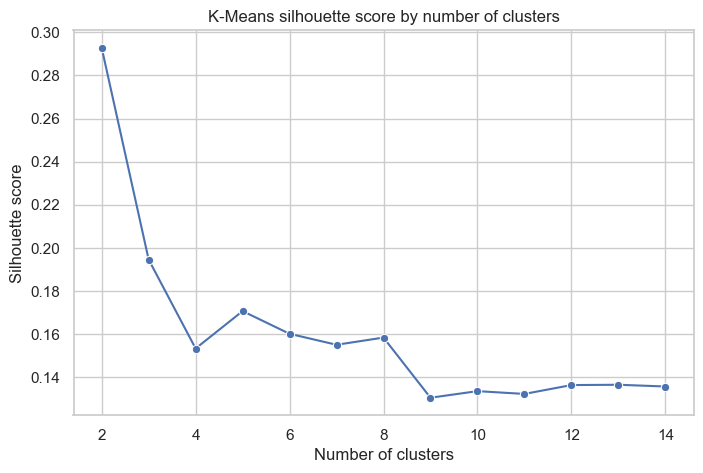

In [26]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("K-Means silhouette score by number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

### Interpretation

The silhouette score is highest for 2 clusters, which suggests that the strongest natural division in the data is a broad two-group split rather than a direct match to all individual parties.

For larger numbers of clusters, the score decreases and stays relatively low. This means that forcing the data into many clusters, for example one cluster per party, does not produce clearly separated groups.

Politically, this suggests that candidate answers form broader ideological blocs more clearly than distinct party-level clusters.

## K-Means Clusters on PCA Map

In [29]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
pca_data["kmeans_cluster"] = kmeans.fit_predict(X_all_scaled)

pca_data["kmeans_cluster"] = pca_data["kmeans_cluster"].astype(str)

display(
    pd.crosstab(
        pca_data["kmeans_cluster"],
        pca_data["parti"],
        normalize="index"
    ).round(2)
)

parti,Alternativet,Danmarksdemokraterne,Dansk Folkeparti,Det Konservative Folkeparti,Enhedslisten,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Kristendemokraterne,Liberal Alliance,Løsgænger,Moderaterne,Nye Borgerlige,Radikale Venstre,Socialdemokratiet,Socialistisk Folkeparti,Venstre
kmeans_cluster,,,,,,,,,,,,,,,
0,0.00,0.08,0.11,0.21,0.00,0.00,0.05,0.15,0.0,0.07,0.11,0.00,0.02,0.00,0.19
1,0.16,0.00,0.00,0.00,0.18,0.06,0.05,0.00,0.0,0.03,0.00,0.16,0.19,0.17,0.00


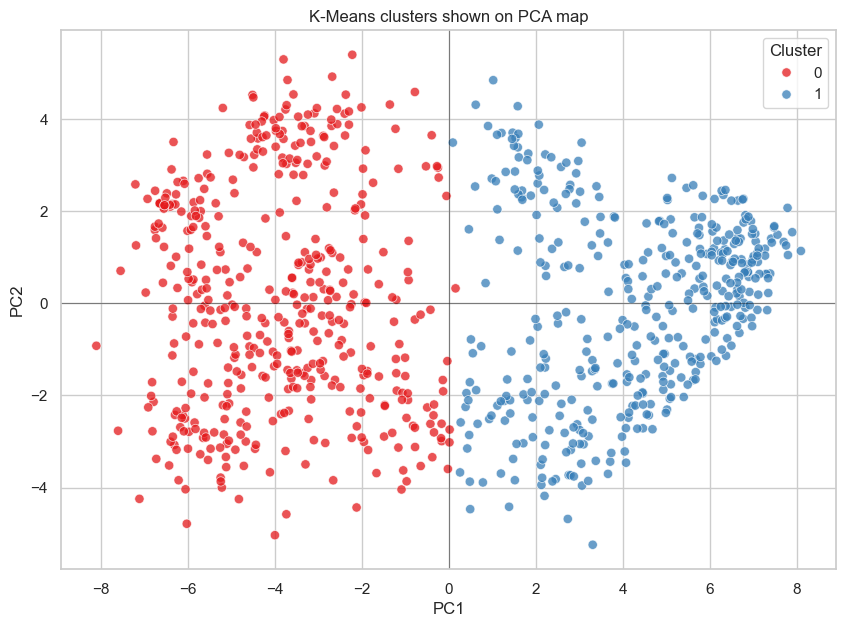

In [30]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="Set1",
    alpha=0.75,
    s=45
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title("K-Means clusters shown on PCA map")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### Interpretation

The K-Means result with 2 clusters shows a strong split mainly along PC1. This means that the broadest natural division in the data is not between all individual parties, but between two larger ideological blocs.

Cluster 1 contains more left-wing and progressive parties such as Enhedslisten, Socialistisk Folkeparti, Radikale Venstre, Alternativet, and Socialdemokratiet. Cluster 0 contains more right-wing, liberal, and conservative parties such as Liberal Alliance, Det Konservative Folkeparti, Venstre, Nye Borgerlige, and Dansk Folkeparti.

This supports the earlier PCA interpretation: PC1 captures a broad political left-right dimension related to welfare, redistribution, inequality, and climate policy.

### K-Means with More Clusters

In [32]:
chosen_k = 5

kmeans_5 = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
pca_data["kmeans_cluster_5"] = kmeans_5.fit_predict(X_all_scaled).astype(str)

display(
    pd.crosstab(
        pca_data["kmeans_cluster_5"],
        pca_data["parti"],
        normalize="index"
    ).round(2)
)

parti,Alternativet,Danmarksdemokraterne,Dansk Folkeparti,Det Konservative Folkeparti,Enhedslisten,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Kristendemokraterne,Liberal Alliance,Løsgænger,Moderaterne,Nye Borgerlige,Radikale Venstre,Socialdemokratiet,Socialistisk Folkeparti,Venstre
kmeans_cluster_5,,,,,,,,,,,,,,,
0,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.98,0.01,0.00
1,0.24,0.00,0.00,0.00,0.33,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00
2,0.00,0.00,0.00,0.37,0.00,0.00,0.00,0.28,0.00,0.04,0.01,0.00,0.00,0.00,0.30
3,0.00,0.26,0.34,0.01,0.00,0.00,0.00,0.00,0.01,0.00,0.35,0.00,0.00,0.00,0.03
4,0.09,0.00,0.00,0.01,0.00,0.00,0.24,0.00,0.01,0.20,0.00,0.41,0.01,0.01,0.02


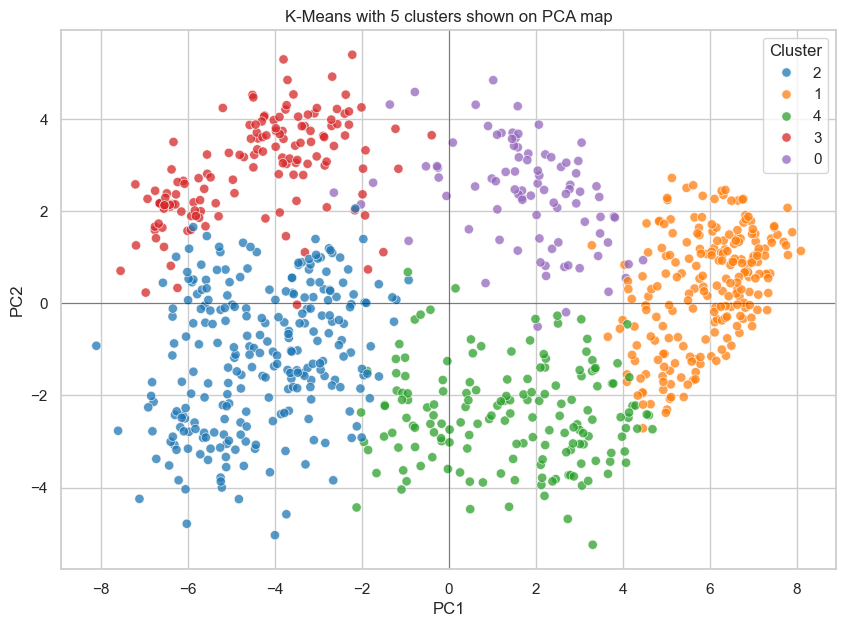

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster_5",
    palette="tab10",
    alpha=0.75,
    s=45
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title("K-Means with 5 clusters shown on PCA map")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

### Interpretation

The 5-cluster K-Means solution gives a more detailed view than the 2-cluster model. It still follows the main PCA structure, but separates candidates into smaller subgroups across both PC1 and PC2.

This suggests that the data contains one strong broad division, shown by the 2-cluster result, and several weaker subgroups inside that division. The choice of 5 clusters is exploratory: it had one of the better silhouette scores after 2 clusters and shows more political nuance without forcing one cluster per party.

The clusters still do not correspond perfectly to individual parties, which suggests that parties overlap in their candidate responses and are better understood as broader ideological regions than fully separate groups.

## Hierarchical Clustering of Parties

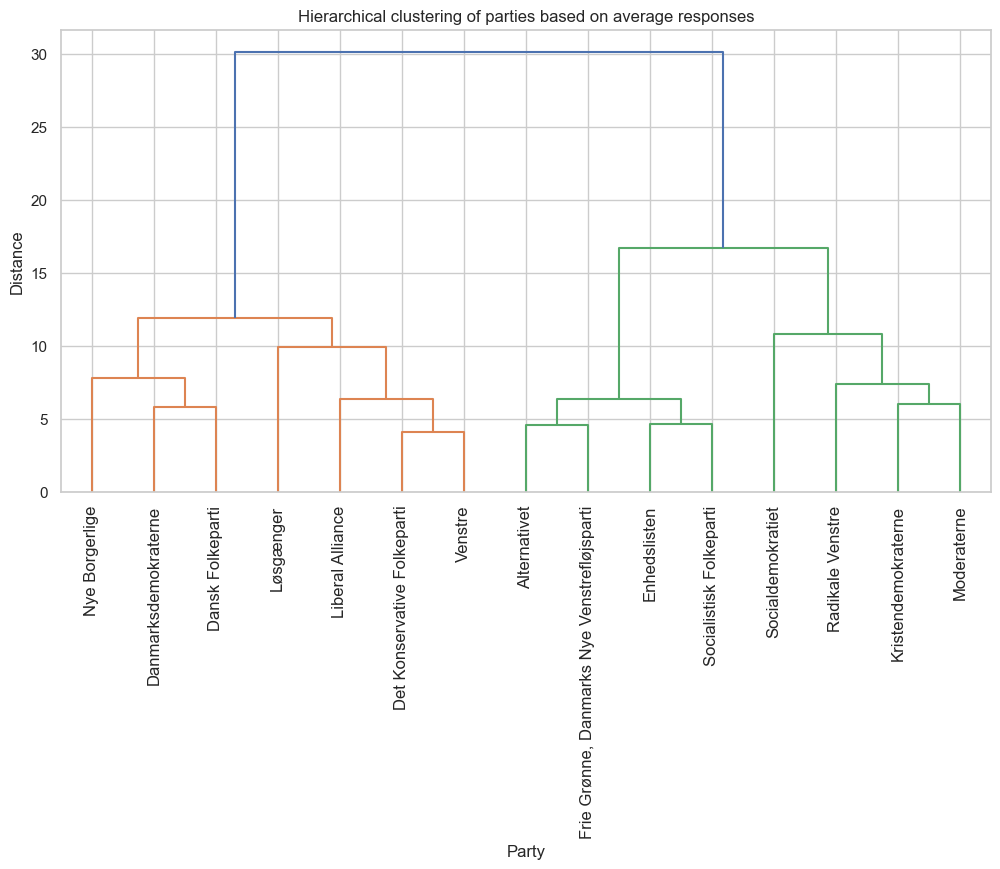

In [34]:
party_profiles = all_clean_data.groupby("parti")[feature_cols].mean()

linked = linkage(party_profiles, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    labels=party_profiles.index,
    leaf_rotation=90
)

plt.title("Hierarchical clustering of parties based on average responses")
plt.xlabel("Party")
plt.ylabel("Distance")
plt.show()

### Interpretation

The dendrogram again shows two broad political blocs. Right-wing/liberal/conservative parties cluster on one side, while left-wing/green/social-liberal parties cluster on the other.

This is consistent with the K-Means result and supports the idea that the strongest structure in the data is a broad ideological split, not one clean cluster per party.

Some smaller party similarities are also visible, for example Enhedslisten with Socialistisk Folkeparti and Det Konservative Folkeparti with Venstre.

## DBSCAN Clustering

In [35]:
eps_values = [2, 3, 4, 5, 6, 7, 8]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_all_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise
    })

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df)

,eps,clusters,noise_points
0,2,3,843
1,3,5,767
2,4,5,549
3,5,1,218
4,6,1,46
5,7,1,7
6,8,1,2


Since the first DBSCAN test showed the biggest change between `eps = 4` and `eps = 6`, this interval was checked in more detail.

In [36]:
eps_values = np.arange(4.0, 6.1, 0.25)

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_all_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise
    })

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df)

,eps,clusters,noise_points
0,4.00,5,549
1,4.25,7,457
2,4.50,5,363
3,4.75,2,291
4,5.00,1,218
5,5.25,2,150
6,5.50,1,104
7,5.75,1,68
8,6.00,1,46


### Interpretation

DBSCAN does not produce a stable or meaningful multi-cluster structure for this dataset. Smaller `eps` values classify too many candidates as noise, while larger `eps` values merge almost all candidates into one cluster. This suggests that the candidate responses form a continuous political landscape rather than clearly separated dense groups.

## Elected Candidates Political Landscape

In [37]:
elected_scaled = scaler.transform(X_elected)
elected_pca_points = pca.transform(elected_scaled)

elected_pca_data = elected_clean_data[["navn", "parti", "storkreds", "alder"]].copy()
elected_pca_data["PC1"] = elected_pca_points[:, 0]
elected_pca_data["PC2"] = elected_pca_points[:, 1]

display(elected_pca_data.head())

,navn,parti,storkreds,alder,PC1,PC2
0,Karsten Hønge,Socialistisk Folkeparti,Fyns Storkreds,64.0,6.091749,1.191952
1,Torsten Gejl,Alternativet,Østjyllands Storkreds,58.0,6.633397,0.305593
2,Mai Villadsen,Enhedslisten,Østjyllands Storkreds,30.0,6.875018,0.842990
3,Hans Kristian Skibby,Danmarksdemokraterne,Østjyllands Storkreds,53.0,-3.313768,3.845314
4,Troels Lund Poulsen,Venstre,Østjyllands Storkreds,46.0,-3.065253,1.393240


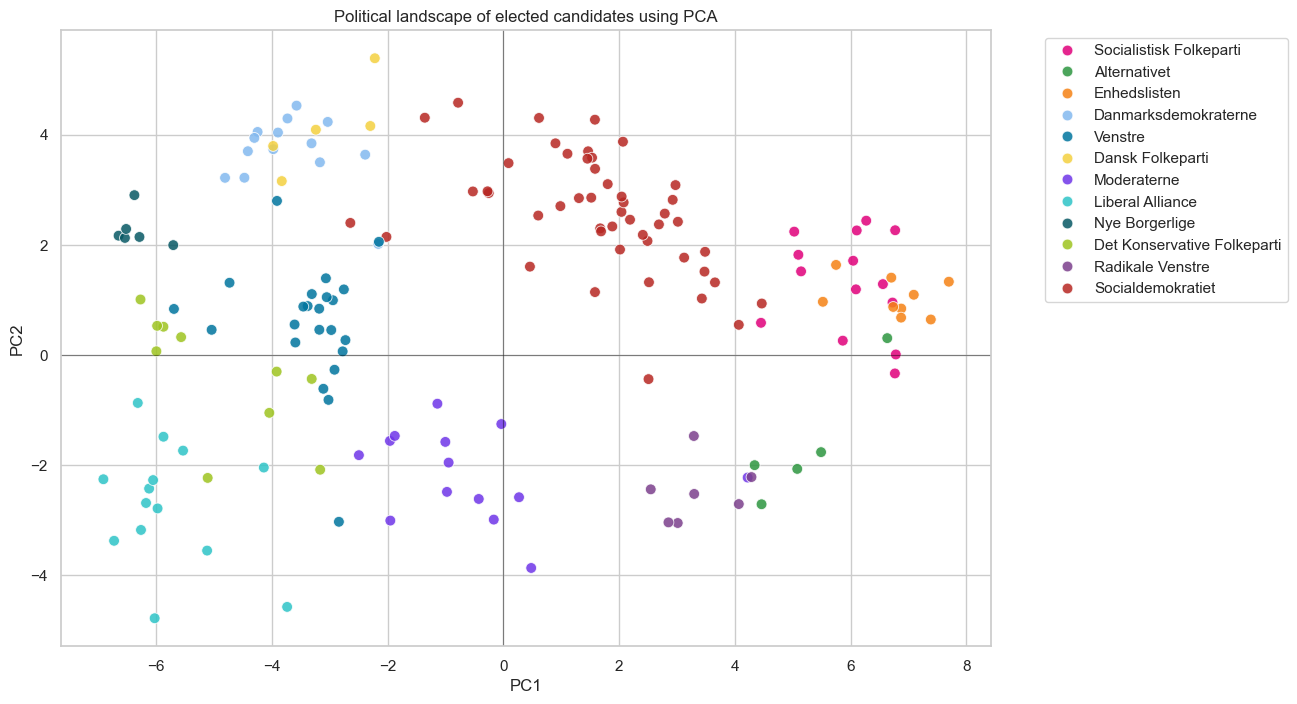

In [39]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=elected_pca_data,
    x="PC1",
    y="PC2",
    hue="parti",
    palette=party_colors,
    alpha=0.85,
    s=60
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title("Political landscape of elected candidates using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Interpretation

The elected candidates form visible party-based regions, but the parties are not perfectly separated.

The map follows the earlier PCA pattern: PC1 mainly separates broad welfare, inequality, climate, and redistribution positions. The sign of PC1 is arbitrary, so left/right on the plot should not be read directly as political left/right.

This plot only includes elected candidates who participated in the tests.

## Agreement and Disagreement among Elected Candidates

In [40]:
distance_matrix = squareform(pdist(elected_scaled, metric="euclidean"))

distance_pairs = pd.DataFrame(
    np.argwhere(np.triu(np.ones(distance_matrix.shape), k=1).astype(bool)),
    columns=["idx_1", "idx_2"]
)

distance_pairs["distance"] = distance_matrix[
    distance_pairs["idx_1"],
    distance_pairs["idx_2"]
]

distance_pairs["candidate_1"] = elected_clean_data.iloc[distance_pairs["idx_1"]]["navn"].values
distance_pairs["candidate_2"] = elected_clean_data.iloc[distance_pairs["idx_2"]]["navn"].values

distance_pairs["party_1"] = elected_clean_data.iloc[distance_pairs["idx_1"]]["parti"].values
distance_pairs["party_2"] = elected_clean_data.iloc[distance_pairs["idx_2"]]["parti"].values

distance_pairs = distance_pairs[
    ["candidate_1", "party_1", "candidate_2", "party_2", "distance"]
]

most_similar = distance_pairs.sort_values("distance").head(10)
most_different = distance_pairs.sort_values("distance", ascending=False).head(10)

display(most_similar)
display(most_different)

,candidate_1,party_1,candidate_2,party_2,distance
12387,Pernille Vermund,Nye Borgerlige,Peter Seier Christensen,Nye Borgerlige,0.637102
10349,Trine Bramsen,Socialdemokratiet,Rasmus Stoklund,Socialdemokratiet,1.011749
8924,Lea Wermelin,Socialdemokratiet,Rasmus Stoklund,Socialdemokratiet,1.047095
1142,Jakob Ellemann-Jensen,Venstre,Karen Ellemann,Venstre,1.234518
7829,Kim Edberg,Nye Borgerlige,Peter Seier Christensen,Nye Borgerlige,1.424936
8854,Lea Wermelin,Socialdemokratiet,Trine Bramsen,Socialdemokratiet,1.456038
7807,Kim Edberg,Nye Borgerlige,Pernille Vermund,Nye Borgerlige,1.560878
13858,Sophie Løhde,Venstre,Karen Ellemann,Venstre,1.788974
1128,Jakob Ellemann-Jensen,Venstre,Sophie Løhde,Venstre,1.839540
8612,Ane Halsboe-Jørgensen,Socialdemokratiet,Rasmus Stoklund,Socialdemokratiet,1.900078


,candidate_1,party_1,candidate_2,party_2,distance
12342,Karina Lorentzen Dehnhardt,Socialistisk Folkeparti,Steffen Frølund,Liberal Alliance,16.199810
6669,Peder Hvelplund,Enhedslisten,Steffen Frølund,Liberal Alliance,16.186415
6684,Peder Hvelplund,Enhedslisten,Steffen Larsen,Liberal Alliance,15.836270
12324,Karina Lorentzen Dehnhardt,Socialistisk Folkeparti,Sandra Elisabeth Skalvig,Liberal Alliance,15.815183
2696,Kirsten Normann Andersen,Socialistisk Folkeparti,Steffen Frølund,Liberal Alliance,15.756654
5356,Ole Birk Olesen,Liberal Alliance,Karina Lorentzen Dehnhardt,Socialistisk Folkeparti,15.729006
11012,Signe Munk,Socialistisk Folkeparti,Steffen Frølund,Liberal Alliance,15.701456
6651,Peder Hvelplund,Enhedslisten,Sandra Elisabeth Skalvig,Liberal Alliance,15.694369
2544,Charlotte Broman Mølbæk,Socialistisk Folkeparti,Steffen Frølund,Liberal Alliance,15.667275
4442,Rosa Lund,Enhedslisten,Steffen Frølund,Liberal Alliance,15.628210


### Interpretation

The most similar elected candidates are mostly from the same party, especially within Nye Borgerlige, Socialdemokratiet, and Venstre. This suggests that candidates from the same party often answer the test in very similar ways.

The most different pairs are mainly between left-wing parties such as Enhedslisten or Socialistisk Folkeparti and Liberal Alliance. This matches the earlier PCA and clustering results, where these parties were placed far apart in the political landscape.

## Internal disagreement within parties

In [41]:
party_disagreement = []

for party, group in elected_clean_data.groupby("parti"):
    if len(group) < 2:
        continue
    
    group_positions = elected_scaled[group.index]
    distances = pdist(group_positions, metric="euclidean")
    
    party_disagreement.append({
        "party": party,
        "n_candidates": len(group),
        "mean_internal_distance": distances.mean(),
        "max_internal_distance": distances.max()
    })

party_disagreement_df = pd.DataFrame(party_disagreement).sort_values(
    "mean_internal_distance",
    ascending=False
)

display(party_disagreement_df)

,party,n_candidates,mean_internal_distance,max_internal_distance
2,Dansk Folkeparti,5,6.299456,7.207023
0,Alternativet,5,6.188524,7.863387
5,Liberal Alliance,14,6.105916,10.106064
6,Moderaterne,14,6.041494,8.960296
3,Det Konservative Folkeparti,10,5.833353,8.435081
9,Socialdemokratiet,48,5.589947,9.628654
8,Radikale Venstre,7,5.057365,6.902151
11,Venstre,23,5.042051,8.269777
10,Socialistisk Folkeparti,14,4.666759,6.770315
1,Danmarksdemokraterne,14,4.548252,7.591701


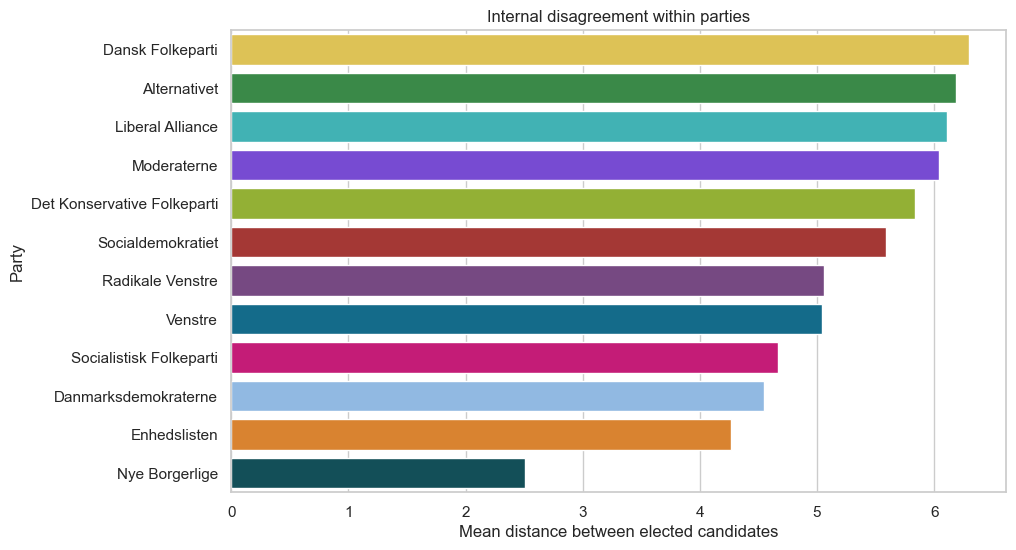

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=party_disagreement_df,
    x="mean_internal_distance",
    y="party",
    hue="party",
    palette=party_colors,
    legend=False
)

plt.title("Internal disagreement within parties")
plt.xlabel("Mean distance between elected candidates")
plt.ylabel("Party")
plt.show()

### Interpretation

Dansk Folkeparti, Alternativet, Liberal Alliance, and Moderaterne show the highest internal disagreement among their elected candidates. This means their elected members are more spread out in their test responses.

Nye Borgerlige has the lowest internal disagreement, suggesting that its elected candidates answered more similarly to each other.

These results should be interpreted with party size in mind, because parties with fewer elected candidates can have less stable average distances.

## Conclusion

The analysis shows that the candidate responses mainly form broad ideological blocs rather than one clear cluster per party. PCA, K-Means, and hierarchical clustering all point to a strong left-right style division connected to welfare, inequality, redistribution, climate, immigration, and EU-related questions.

K-Means worked best with 2 clusters, while 5 clusters gave a more detailed but less clearly separated structure. Hierarchical clustering showed similar broad party groupings. DBSCAN was less suitable, because the data forms a continuous political landscape rather than clearly separated dense clusters.

For elected candidates, parties form visible regions on the PCA map, but there is still overlap. The most different candidate pairs are mainly between left-wing parties and Liberal Alliance, while the most similar pairs are often from the same party.

## Limitations

The elected candidates dataset only includes elected members who participated in the candidate tests, so it does not represent the complete parliament.

PCA only shows a two-dimensional approximation of the full response data, so some information is lost.

The clustering results depend on preprocessing choices and model parameters, especially for K-Means and DBSCAN.